### What is Early Stopping ?
<hr>
In machine learning, early stopping is a form of regularization used to avoid overfitting when training a model with an iterative method, such as gradient descent. Such methods update the model to make it better fit the training data with each iteration. Up to a point, this improves the model's performance on data outside of the training set (e.g., the validation set). Past that point, however, improving the model's fit to the training data comes at the expense of increased generalization error. Early stopping rules provide guidance as to how many iterations can be run before the learner begins to over-fit. Early stopping rules have been employed in many different machine learning methods, with varying amounts of theoretical foundation.
<hr>
<br>reference : https://en.wikipedia.org/wiki/Early_stopping

In [1]:
# Now lets understand this with a code example

In [3]:
# First import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense,Input
from tensorflow.keras.callbacks import EarlyStopping


In [79]:
# Now we will use the make_circles function to build a dataset .

X,y = make_circles(
                    n_samples = 250,
                    random_state = 9,
                    noise = 0.1
)

In [35]:
X.shape,y.shape # <_- The shape of the X and y set

((250, 2), (250,))

In [36]:
X[:5],y[:5] # The top 5 rows of both

(array([[-0.29883907, -1.11759445],
        [-0.68324367, -0.73611173],
        [ 0.77534536, -0.22351134],
        [ 0.213691  ,  0.89495776],
        [-0.53641262, -0.40363538]]),
 array([0, 0, 1, 1, 1]))

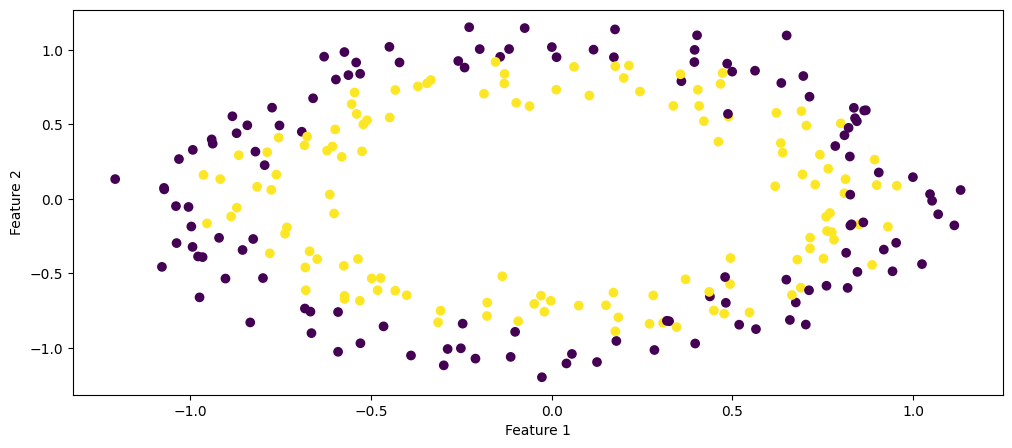

In [37]:
# Now lets plot this data to understand it better

plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [38]:
# Also lets split the dataset so that we can have our training and testing set , which will be used for our model evaluation later

In [80]:
X_train ,X_test ,y_train ,y_test = train_test_split(
                                                        X,y,
                                                        test_size = 0.2,
                                                        random_state = 9
)

In [42]:
# Skimming the no of rows in each set 

In [41]:
X_train.shape,y_train.shape

((200, 2), (200,))

In [43]:
X_test.shape,y_test.shape

((50, 2), (50,))

In [44]:
# Now lets build the model
# As seen before this is a classification problem we will be using the sigmoid function as A(f) for output and we will be using ReLu for other layers.
# Also we will choose a single layer with large number of neurons to properly demonstrate this concept
# And we will use binary_crossentropy as loss function and adam as optimizer given the problem

In [45]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [47]:
model.summary() # The model summary

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Now compile it accordingly 
model.compile(
                loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy']
            )

In [50]:
# Now lets train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500)
# Store it in epochs as we will use the training set and testing set to compare the loss w.t.r to epochs

Epoch 1/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6550 - loss: 0.6409 - val_accuracy: 0.3800 - val_loss: 0.7012
Epoch 2/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6850 - loss: 0.6379 - val_accuracy: 0.4200 - val_loss: 0.6988
Epoch 3/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6900 - loss: 0.6361 - val_accuracy: 0.4200 - val_loss: 0.6971
Epoch 4/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6900 - loss: 0.6329 - val_accuracy: 0.4200 - val_loss: 0.6971
Epoch 5/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7100 - loss: 0.6313 - val_accuracy: 0.4200 - val_loss: 0.6984
Epoch 6/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7050 - loss: 0.6293 - val_accuracy: 0.4200 - val_loss: 0.6958
Epoch 7/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7050 - loss: 0.6270 - val_accuracy: 0.4200 - val_loss: 0.6960
Epoch 8/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6900 - loss: 0.6247 - val_accuracy: 0.4200 - v

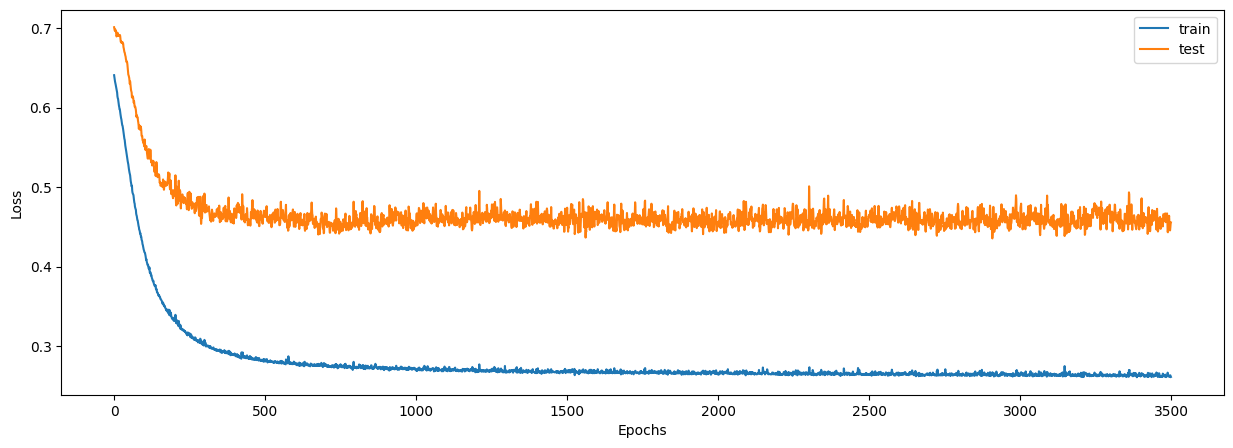

In [51]:
# Now lets plot this into the graph
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [53]:
# As we can clearly see how model overfits after a certain epoch value near 300

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step


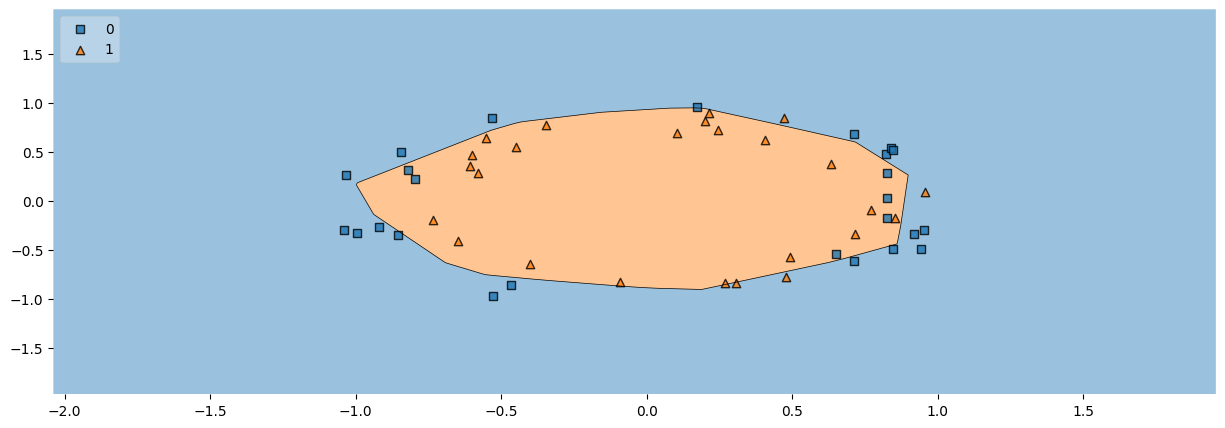

In [52]:
# Also plot the decision boundary to look for how well the model fits the data
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [54]:
# Now lets use early stopping and get it's performance

In [55]:
# The whole model building will be same except the fact that we are going to pass the callback hash to callback with parameters of early stopping

In [86]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [87]:
# Now make the callback function
callback = EarlyStopping(
    monitor="val_loss", # What to check for convergence
    min_delta=0.00001, # Minimum change to check , hyperparameter
    patience=20, # How long should it wait to check for no change
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [88]:
# Now train
history = model.fit(
                    X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=3500,
                    callbacks=callback # <--- Make sure to pass this 
                    )

Epoch 1/3500


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.4900 - loss: 0.6957 - val_accuracy: 0.4200 - val_loss: 0.6963
Epoch 2/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5050 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6961
Epoch 3/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6885 - val_accuracy: 0.5000 - val_loss: 0.6977
Epoch 4/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.6863 - val_accuracy: 0.5000 - val_loss: 0.6984
Epoch 5/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.6849 - val_accuracy: 0.5000 - val_loss: 0.6995
Epoch 6/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.6836 - val_accuracy: 0.5000 - val_loss: 0.7008
Epoch 7/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 0.6817 - val_accuracy: 0.5000 - val_loss: 0.7013
Epoch 8/3500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.6802 - val_accuracy: 0.5000 - val_loss: 0.70

In [ ]:
# As you can see that this literally took 22 epochs to stop !!!

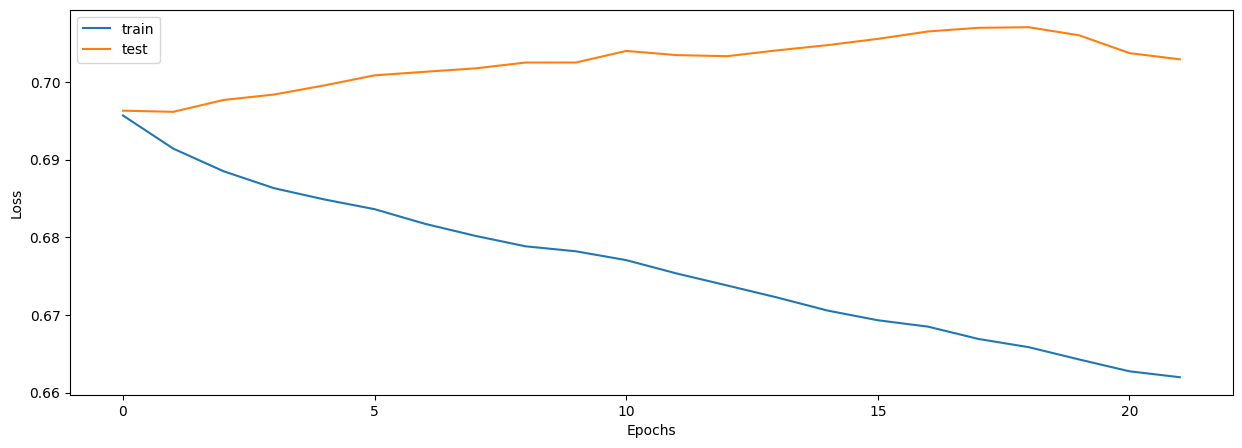

In [90]:
# Now plotting
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step


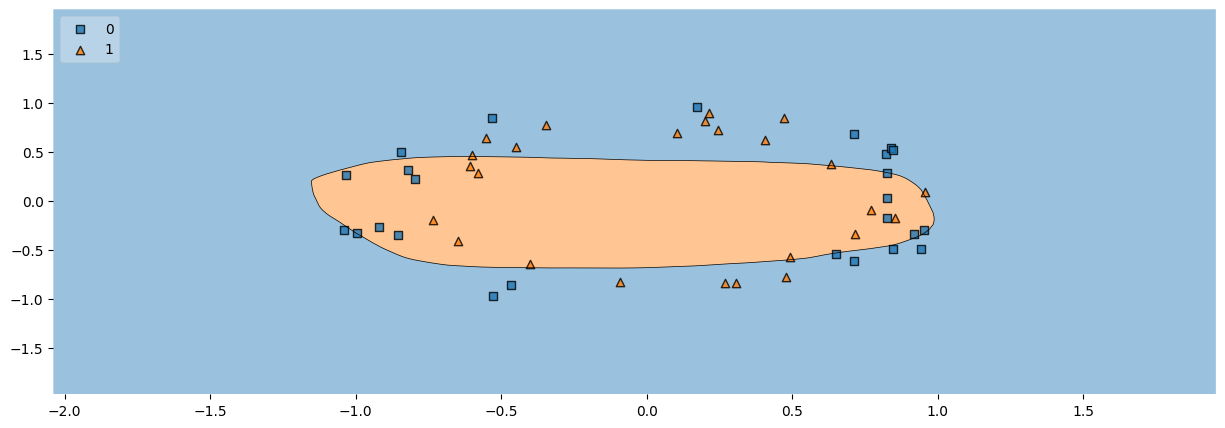

In [91]:
# Also plot the decision boundary to look for how well the model fits the data
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [92]:
# I have exerimented a lot but Idk why the stopping value here is quite low even though a higher value is expected